# Aprendizagem Não Supervisionada

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
np.random.seed(42)

## Geração do Dataset

São gerados dois sets de 500 pontos 2D com distribuições gaussianas multivariadas:

- **Set A**: média (3,3), covariância [[1, 0], [0, 1]]
- **Set B**: média (-3,-3), covariância [[2, 0], [0, 5]]

**Labels:** É acrescentada uma terceira coluna com a origem de cada ponto: 1 para o set A e 2 para o set B; Servirá apenas para avaliar se os grupos descobertos pelos algoritmos correspondem às distribuições reais.

**Preparação:** Os dois sets foram concatenados numa matriz 1000 x 3 e baralhados, para que a ordem dos pontos não revele a sua origem


In [2]:
mean_a = [3, 3]
cov_a = [[1, 0], [0, 1]]
a = np.random.multivariate_normal(mean_a, cov_a, 500)  # 500 x 2

mean_b = [-3, -3]
cov_b = [[2, 0], [0, 5]]
b = np.random.multivariate_normal(mean_b, cov_b, 500) # 500 x 2

labels_a = np.ones(500)
labels_b = np.full(500, 2)

a = np.column_stack((a, labels_a)) # 500 x 3
b = np.column_stack((b, labels_b)) # 500 x 3

dataset = np.concatenate((a, b), axis=0) # 1000 x 3
np.random.shuffle(dataset)



## Visualização do Dataset 

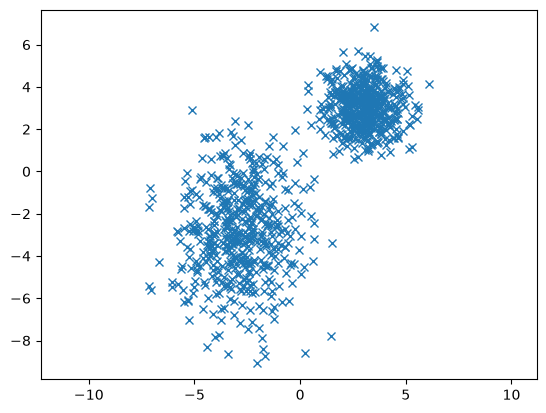

In [3]:
x = dataset[:, 0]
y = dataset[:, 1]

plt.plot(x, y, 'x')
plt.axis('equal')
plt.show()

O gráfico representa as duas primeiras colunas do dataset (`x`e `y`), sem recurso às labels, de modo a representar a informação disponível para os algoritmos de clustering.

Visualmente, os pontos parecem agrupar-se em duas regiões, correspondentes aos sets A e B gerados.

Posteriormente será avaliado se os algoritmos de clustering conseguem identificar os pontos provenientes do set A e do set B de forma não supervisionada.

In [4]:
np.savetxt('dataset.csv', dataset, delimiter=',', header='x,y,label', comments='', fmt=['%.5f', '%.5f', '%d'])

## Implementação de uma versão simples do K-Means

### Preparação dos dados e inicialização dos representantes - alínea 1

As coordenadas dos pontos e as labels são separadas em dois sets distintos: `points` e `labels`respetivamente.
`labels`não é usada pelo algoritmo, servindo apenas posteriormente para avaliação de resultados.

São escolhidos aleatoriamente dois pontos distintos do dataset `points` como representantes iniciais r1 e r1.

A função `distance` calcula a distância euclidiana entre dois pontos. Esta será usada para decidir qual o representa mais próximo de cada ponto.


In [5]:
points = dataset[:, :2]
labels = dataset[:, 2]

indices = np.random.choice(len(points), 2, replace=False)

r1_initial = points[indices[0]]
r2_initial = points[indices[1]]

def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2) ** 2))


### K-Means - alínea 1

A função `kmeans` percorre todos os pontos do dataset em cada epoch. Para cada ponto, é calculado a distância deste para r1 e r2 e atualiza **apenas o representante mais próximo**.

Esta devolve, para cada representante:
- **os seus valores consecutivos** (`r1_history`, `r2_history`)
- **os seus valores por epochs** (`r1_epochs`, `r2_epochs`)

In [6]:
def kmeans(points, alpha, epochs, r1_initial, r2_initial):
    r1 = r1_initial.copy()
    r2 = r2_initial.copy()

    r1_history = [r1.copy()]
    r2_history = [r2.copy()]

    r1_epochs = [r1.copy()]
    r2_epochs = [r2.copy()]

    for epoch in range(epochs):
        for point in points:
            d1 = distance(point, r1)
            d2 = distance(point, r2)

            if d1 <= d2:
                r1 = (1-alpha) * r1 + alpha * point
                r1_history.append(r1.copy())
            else:
                r2 = (1-alpha) * r2 + alpha * point
                r2_history.append(r2.copy())

        r1_epochs.append(r1.copy())
        r2_epochs.append(r2.copy())

    return (np.array(r1_history), np.array(r2_history), np.array(r1_epochs), np.array(r2_epochs))

### K-Means com diferentes alphas - alínea 2 e 3

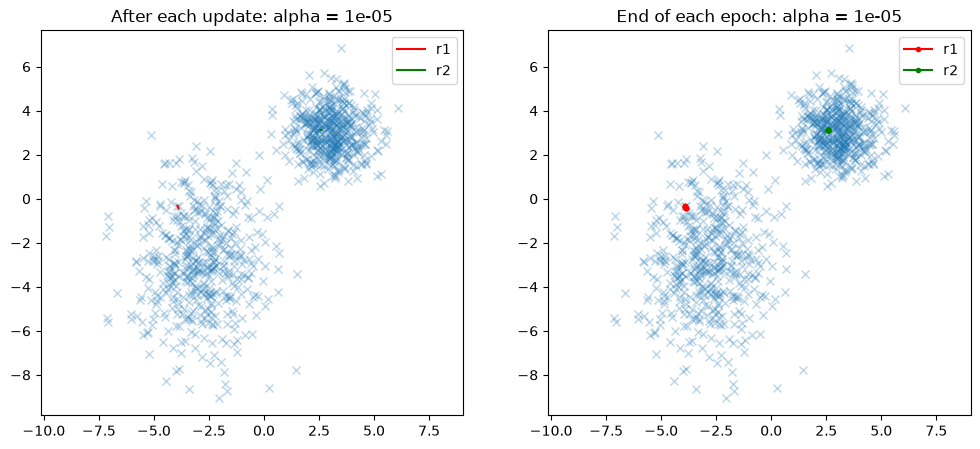

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.87938981 -0.44003292] [2.58097754 3.12528613]


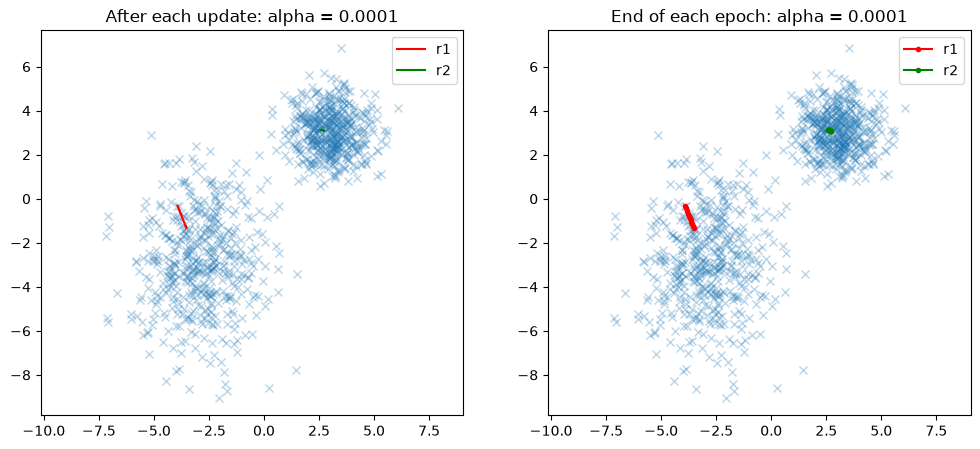

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.52717431 -1.31941842] [2.73110629 3.08815129]


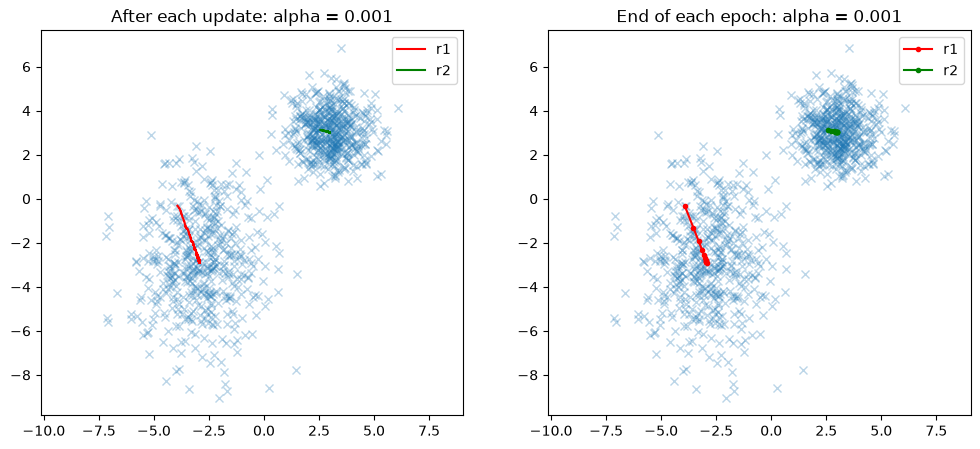

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-2.93763797 -2.89589198] [2.97903068 3.01159853]


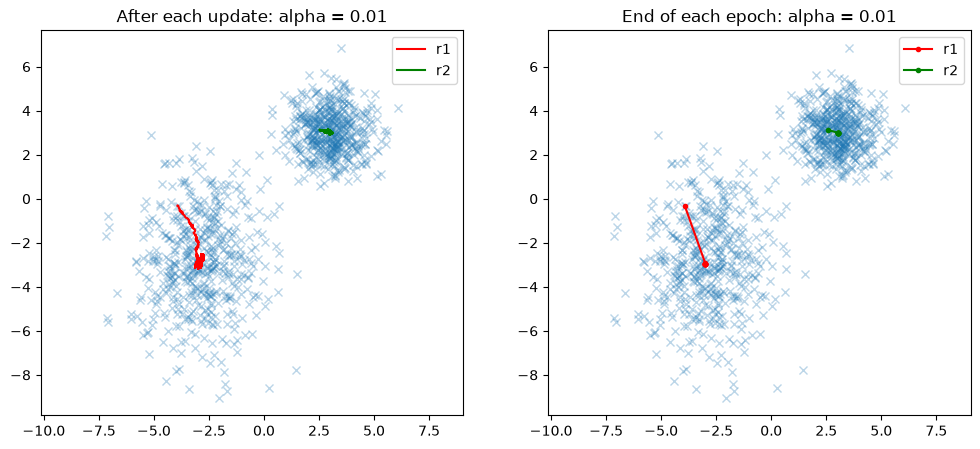

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-2.99362103 -2.94188445] [3.03414547 2.99516671]


In [7]:
alphas = [10E-6, 10E-5, 10E-4, 10E-3]

for alpha in alphas:
    r1_history, r2_history, r1_epochs, r2_epochs = kmeans(points, alpha, 10, r1_initial, r2_initial)

    fig, axs = plt.subplots(1, 2, figsize=(12,5))

    axs[0].plot(points[:,0], points[:,1], 'x', alpha=0.3)
    axs[0].plot(r1_history[:,0], r1_history[:,1], 'r-', label='r1')
    axs[0].plot(r2_history[:,0], r2_history[:,1], 'g-', label='r2')
    axs[0].set_title(f'After each update: alpha = {alpha}')
    axs[0].axis('equal')
    axs[0].legend()

    axs[1].plot(points[:,0], points[:,1], 'x', alpha=0.3)
    axs[1].plot(r1_epochs[:,0], r1_epochs[:,1], 'ro-', markersize=3, label='r1')
    axs[1].plot(r2_epochs[:,0], r2_epochs[:,1], 'go-', markersize=3, label='r2')
    axs[1].set_title(f'End of each epoch: alpha = {alpha}')
    axs[1].axis('equal')
    axs[1].legend()

    plt.show()

    print('Médias reais:', points[labels == 1].mean(axis=0), points[labels == 2].mean(axis=0))
    print('r1, r2 final:', r1_epochs[-1], r2_epochs[-1])

#### Efeito do valor de alpha com 10 epochs 

O K-Means foi executado com 4 valores de alpha: 10^-5, 10^-4, 10^-3 e 10^-2. 
As médias reais dos dois grupos são nomeadamente (3.00, 3.04) e (-2.89, -2.86).

- alpha = 10^-5: os representantes deslocam-se muito pouco. Após 10 epochs, tanto r1 e r2 ainda estão bastante longe da média dos respetivo grupos. O valor de alpha é tão pequeno que 10 epochs não são suficientes para que os representantes se aproximem dos centros.
- alpha = 10^-4: os representantes já apresentam uma maior deslocação em direção aos centros, embora ainda não tenham chegado completamente às médias dos dois grupos.
- alpha = 10^-3: Os representantes ficam muito próximos das médias reais dos dois grupos.
- alpha = 10^-2: Os represantes também ficam muito próximos das médias reais dos dois grupos. No gráfico que mostra a evolução dos representantes ponto a ponto é possivel observar oscilações em torno do centro. Isto demonstra que cada ponto tem uma grande influência na atualização dos representantes para às medias reais dos respetivos grupos.

**Nota:** O primeiro gráfico mostra todas as atualizações dos representantes, pelo que é possível observar os pequenos movimentos provocados por cada ponto. O segundo gráfico mostra apenas a posição dos representantes no final de cada epoch, permitindo observar de forma mais clara a direção e a velocidade da sua evolução.



### K-Means com diferentes epochs - alínea 2 e 3

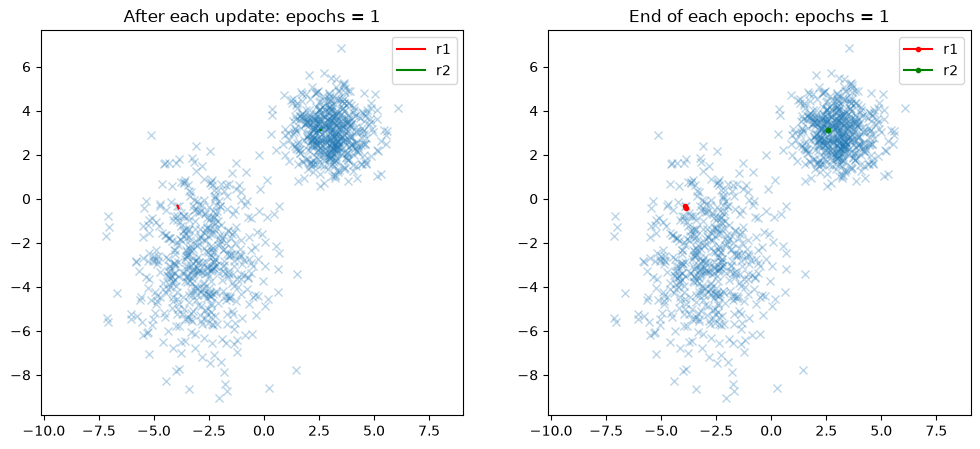

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.87994514 -0.44013197] [2.58075442 3.12487666]


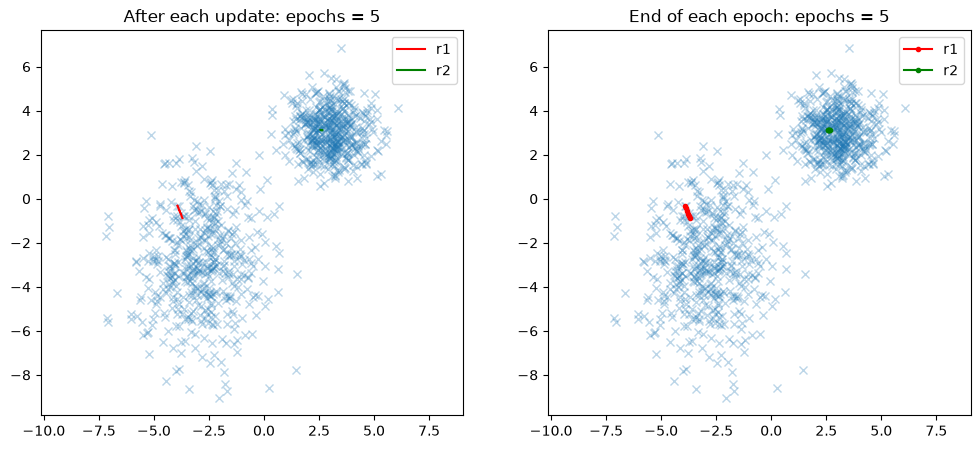

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.70355634 -0.87978362] [2.65599889 3.10649723]


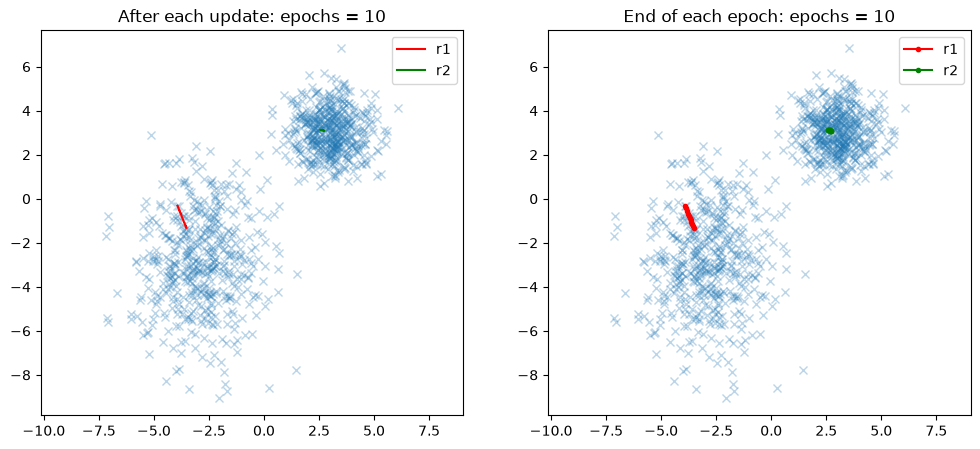

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.52717431 -1.31941842] [2.73110629 3.08815129]


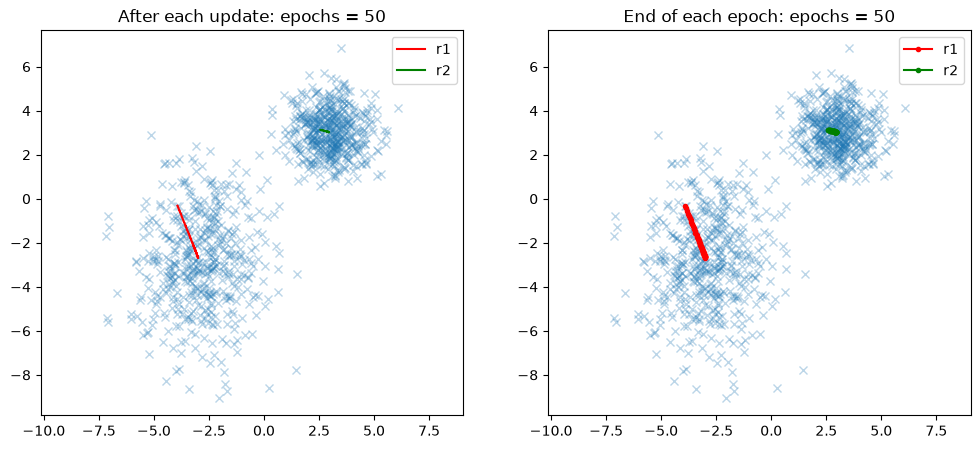

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-2.99737224 -2.67570616] [2.94522522 3.0249125 ]


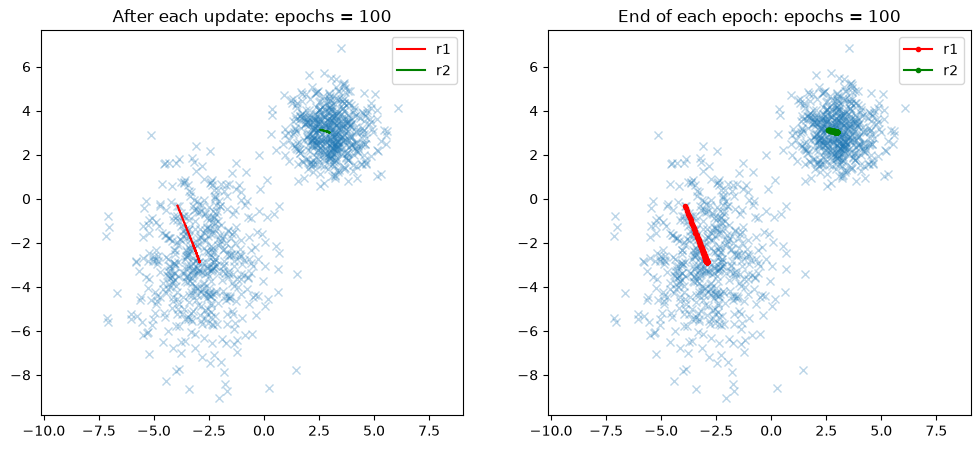

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-2.92316864 -2.87949908] [2.96987263 3.01336275]


In [8]:
epochs_list = [1, 5, 10, 50, 100]

for epochs in epochs_list:
     r1_history, r2_history, r1_epochs, r2_epochs = kmeans(points, 10E-5, epochs, r1_initial, r2_initial)
    
     fig, axs = plt.subplots(1, 2, figsize=(12,5))
    
     axs[0].plot(points[:,0], points[:,1], 'x', alpha=0.3)
     axs[0].plot(r1_history[:,0], r1_history[:,1], 'r-', label='r1')
     axs[0].plot(r2_history[:,0], r2_history[:,1], 'g-', label='r2')
     axs[0].set_title(f'After each update: epochs = {epochs}')
     axs[0].axis('equal')
     axs[0].legend()
            
     axs[1].plot(points[:,0], points[:,1], 'x', alpha=0.3)
     axs[1].plot(r1_epochs[:,0], r1_epochs[:,1], 'ro-', markersize=3, label='r1')
     axs[1].plot(r2_epochs[:,0], r2_epochs[:,1], 'go-', markersize=3, label='r2')
     axs[1].set_title(f'End of each epoch: epochs = {epochs}')
     axs[1].axis('equal')
     axs[1].legend()
            
     plt.show()

     print('Médias reais:', points[labels == 1].mean(axis=0), points[labels == 2].mean(axis=0))
     print('r1, r2 final:', r1_epochs[-1], r2_epochs[-1])
    

#### Efeito dos valores de epochs com alpha = 10^-4

Com alpha fixo, foi testado o k-means com diferentes epochs: 1, 5, 10, 50, 100.

- É possivel observar de forma clara, que quanto maior o número de epochs, maior é a aproximação dos representantes em relação às médias reais.

**Nota:** O primeiro gráfico mostra todas as atualizações dos representantes, pelo que é possível observar os pequenos movimentos provocados por cada ponto. O segundo gráfico mostra apenas a posição dos representantes no final de cada epoch, permitindo observar de forma mais clara a direção e a velocidade da sua evolução.


### Conclusões - alínea 3

- Os representantes começam em dois pontos aleatórios do dataset e deslocam-se até ao centro de um dos grupos.
- A velocidade de deslocamento dos representantes até ao centro dos grupos depende do alpha e do número de epochs:
  - Um alpha pequeno produz uma trajetória mais lenta e suave, sendo necessárias mais epochs para que os representantes se aproximem dos centros;
  - Um alpha maior faz com que os representantes se desloquem mais rapidamente, podendo também provocar mais oscilações em torno do centro, dado que cada ponto tem uma maior influência na atualização;
- Os parâmetros dos dados tiveram impacto nos valores finais de r1 e r2 na medida que estes são atualizados com base nos pontos que estão mais próximos. Como os dois grupos estavam bem separados e com pouca sobreposição, estes acabaram por ficar próximos das médias das distribuições que geraram os dados.



### Alínea 4

A função `kmeans_v2` acumula, durante cada epoch, as diferenças entre cada ponto e o representante mais próximo. 

Nesta versão, os representantes r1 e r2 só são atualizados **no final de cada epoch** e não a cada ponto.

In [9]:
def kmeans_v2(points, alpha, epochs, r1_initial, r2_initial):
    r1 = r1_initial.copy()
    r2 = r2_initial.copy()

    r1_epochs = [r1.copy()]
    r2_epochs = [r2.copy()]
    n = len(points)

    for epoch in range(epochs):
        d1 = np.zeros(2)
        d2 = np.zeros(2)

        for point in points:
            if distance(point, r1) <= distance(point, r2):
                d1 += point - r1
            else:
                d2 += point - r2

        r1 = r1 + (alpha/n) * d1
        r2 = r2 + (alpha/n) * d2

        r1_epochs.append(r1.copy())
        r2_epochs.append(r2.copy())

    return (np.array(r1_epochs), np.array(r2_epochs))

    

### Alínea 5

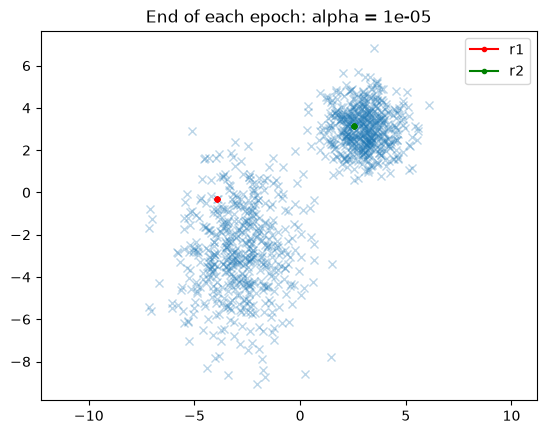

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.92893845 -0.31592024] [2.55997678 3.13073457]


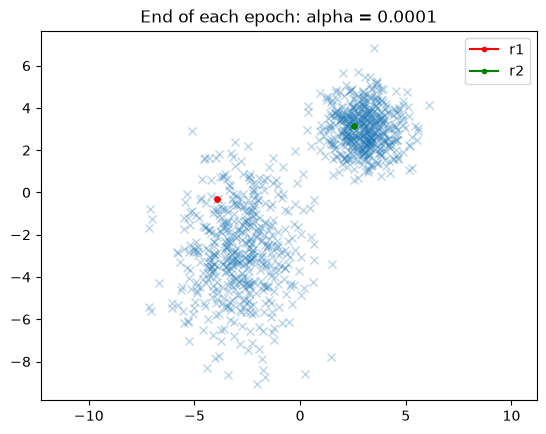

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.92848545 -0.31706607] [2.56016815 3.13068049]


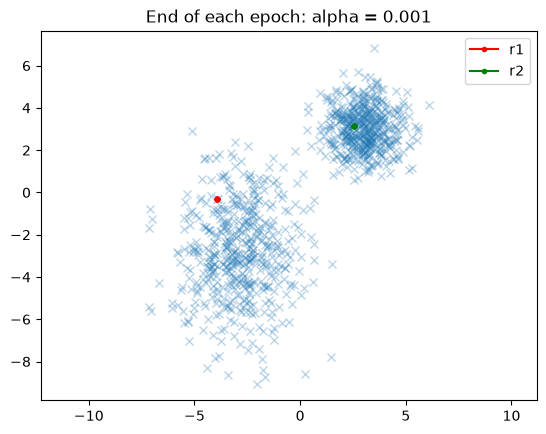

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.92396537 -0.32849902] [2.56207758 3.13014096]


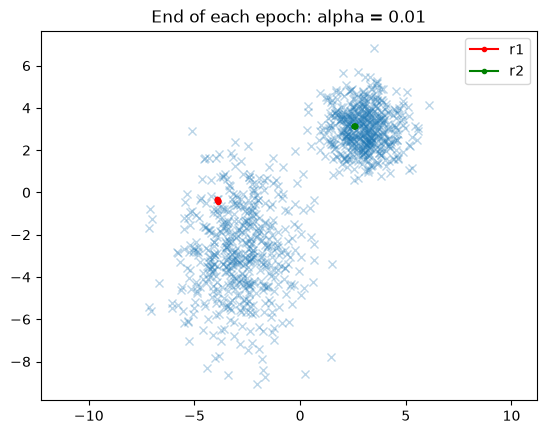

Médias reais: [3.0036012  3.03506291] [-2.88841659 -2.85963958]
r1, r2 final: [-3.87929791 -0.44033288] [2.5809969  3.12524713]


In [10]:
alphas = [10E-6, 10E-5, 10E-4, 10E-3]

for alpha in alphas:
    r1_epochs_b, r2_epochs_b = kmeans_v2(points, alpha, 10, r1_initial, r2_initial)

    plt.plot(points[:,0], points[:,1], 'x', alpha=0.3)
    plt.plot(r1_epochs_b[:,0], r1_epochs_b[:,1], 'ro-', markersize=3, label='r1')
    plt.plot(r2_epochs_b[:,0], r2_epochs_b[:,1], 'go-', markersize=3, label='r2')
    plt.title(f'End of each epoch: alpha = {alpha}')
    plt.axis('equal')
    plt.legend()
    plt.show()

    print('Médias reais:', points[labels == 1].mean(axis=0), points[labels == 2].mean(axis=0))
    print('r1, r2 final:', r1_epochs_b[-1], r2_epochs_b[-1])

**Observações:** Se forem usados os mesmos valores de alpha, esta versão do K-means faz com que os representantes fiquem mais afastados em relação às medias reais das distribuições. Este comportamento deve-se ao facto de existir apenas uma atualização dos representantes por epoch, enquanto que na primeira versão existem cerca de 500 atualizações por epoch para cada representante.


### Classificação de Pontos - alínea 6

In [11]:
def classify(points, labels, r1, r2):
    r1_label1 = []
    r1_label2 = []
    r2_label1 = []
    r2_label2 = []

    for point, label in zip(points, labels):
        d1 = distance(point, r1)
        d2 = distance(point, r2)

        if d1 <= d2:
            if label == 1:
                r1_label1.append(point)
            else:
                r1_label2.append(point)
        else:
            if label == 1:
                r2_label1.append(point)
            else:
                r2_label2.append(point)

    return (np.array(r1_label1).reshape(-1, 2),
            np.array(r1_label2).reshape(-1, 2),
            np.array(r2_label1).reshape(-1, 2),
            np.array(r2_label2).reshape(-1, 2)
            )


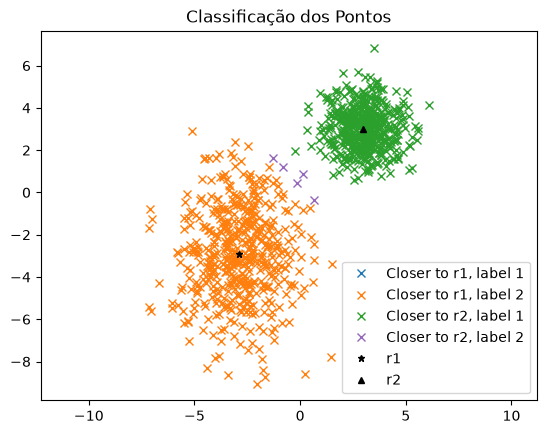

r1, label 1: 0
r1, label 2: 495
r2, label 1: 500
r2, label 2: 5
Pontos bem agrupados: 995/1000 (99.5%)


In [12]:
r1_epochs_b, r2_epochs_b = kmeans_v2(points, 1, 10, r1_initial, r2_initial)

r1_final = r1_epochs_b[-1]
r2_final = r2_epochs_b[-1]

r1_label1, r1_label2, r2_label1, r2_label2 = classify(points, labels, r1_final, r2_final)

plt.plot(r1_label1[:,0], r1_label1[:,1], 'x', color='tab:blue',   label='Closer to r1, label 1')
plt.plot(r1_label2[:,0], r1_label2[:,1], 'x', color='tab:orange', label='Closer to r1, label 2')
plt.plot(r2_label1[:,0], r2_label1[:,1], 'x', color='tab:green',  label='Closer to r2, label 1')
plt.plot(r2_label2[:,0], r2_label2[:,1], 'x', color='tab:purple',    label='Closer to r2, label 2')
plt.plot(*r1_final, 'k*', markersize=5, label='r1')
plt.plot(*r2_final, 'k^', markersize=5, label='r2')
plt.axis('equal')
plt.legend()
plt.title('Classificação dos Pontos')
plt.show()

n = len(points)
acertos = len(r1_label2) + len(r2_label1)
print('r1, label 1:', len(r1_label1))
print('r1, label 2:', len(r1_label2))
print('r2, label 1:', len(r2_label1))
print('r2, label 2:', len(r2_label2))
print(f'Pontos bem agrupados: {acertos}/{n} ({100*acertos/n:.1f}%)')

### Alínea 7

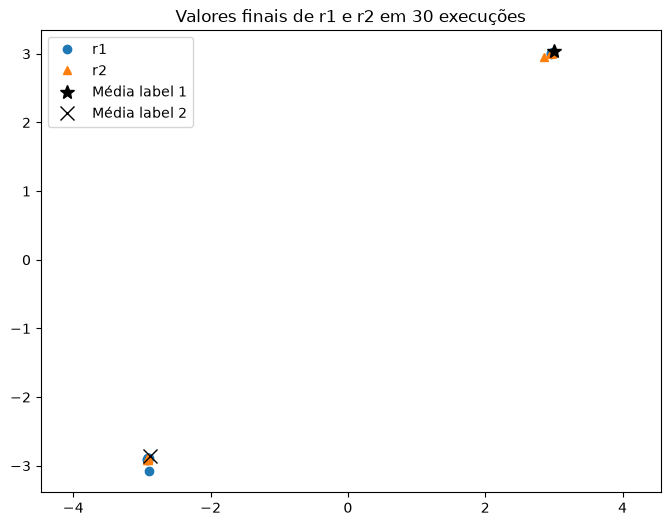

In [13]:
n_trials = 30

r1_final_values = []
r2_final_values = []

for i in range(n_trials):

    indices = np.random.choice(len(points), 2, replace=False)

    r1_initial = points[indices[0]]
    r2_initial = points[indices[1]]

    r1_epochs_b, r2_epochs_b = kmeans_v2(
        points, 1, 10, r1_initial, r2_initial
    )

    r1_final_values.append(r1_epochs_b[-1])
    r2_final_values.append(r2_epochs_b[-1])

r1_final_values = np.array(r1_final_values)
r2_final_values = np.array(r2_final_values)

plt.figure(figsize=(8, 6))

plt.plot(r1_final_values[:, 0], r1_final_values[:, 1],
         'o', label='r1')

plt.plot(r2_final_values[:, 0], r2_final_values[:, 1],
         '^', label='r2')

plt.plot(*points[labels == 1].mean(axis=0),
         'k*', markersize=10, label='Média label 1')

plt.plot(*points[labels == 2].mean(axis=0),
         'kx', markersize=10, label='Média label 2')

plt.axis('equal')
plt.legend()
plt.title('Valores finais de r1 e r2 em 30 execuções')
plt.show()



**Observações:**
- Em todas as tentativas, os representantes terminaram junto das médias reais dos dois grupos, não tendo sido observado nenhum caso de falha de convergência.
- Estes resultados devem-se ao facto de os grupos estarem bem separados.
- A atribuição de r1 e r2 é arbitrária: os dois aparecem próximos das médias reais dos dois grupos. Isto significa que consoante a inicialização, estes podem convergir para os pontos da distribuição A ou B.